# Objectifs d'apprentissage (Learning Outcomes)

À l'issue de cette semaine, l'étudiant sera capable de :

- **Manipuler** les nombres complexes (partie réelle, imaginaire, module, argument, forme polaire).
- **Appliquer** la formule d'Euler pour passer d'une exponentielle complexe à une sinusoïde et vice-versa.
- **Générer** des signaux sinusoïdaux en Python (sinus, cosinus) avec des paramètres d'amplitude, fréquence, phase.
- **Visualiser** des signaux temporels et leurs représentations complexes (partie réelle, imaginaire).
- **Utiliser** les bibliothèques `numpy` et `matplotlib` pour créer et afficher des signaux.
- **Interpréter** l'influence des paramètres (fréquence, phase) sur la forme du signal.

# 1. Rappels sur les nombres complexes

Un nombre complexe $z$ s'écrit sous forme cartésienne :
$$ z = a + j b $$
où $a$ est la partie réelle, $b$ la partie imaginaire, et $j$ l'unité imaginaire ($j^2 = -1$).

## 1.1 Module et argument
- **Module** : $|z| = \sqrt{a^2 + b^2}$
- **Argument** : $\arg(z) = \theta = \operatorname{atan2}(b, a)$ (angle en radians)

Forme polaire :
$$ z = |z| \, e^{j\theta} $$

## 1.2 Conjugué
$$ z^* = a - j b $$

## 1.3 Opérations
- Addition : $(a+jb) + (c+jd) = (a+c) + j(b+d)$
- Multiplication : $(a+jb)(c+jd) = (ac - bd) + j(ad + bc)$
- Division : utiliser le conjugué.

---

## 1.4 Formule d'Euler
$$ e^{j\theta} = \cos \theta + j \sin \theta $$

Conséquences :
- $\cos \theta = \dfrac{e^{j\theta} + e^{-j\theta}}{2}$
- $\sin \theta = \dfrac{e^{j\theta} - e^{-j\theta}}{2j}$

Cette formule est fondamentale en TNS car elle relie les exponentielles complexes aux sinusoïdes.

---

## 1.5 Sinusoïdes
Un signal sinusoïdal s'écrit :
$$ x(t) = A \cos(\omega t + \phi) $$
ou en discret : $x[n] = A \cos(\omega n + \phi)$

où :
- $A$ : amplitude (positive)
- $\omega$ : pulsation (rad/s) ou fréquence angulaire (rad/échantillon en discret)
- $\phi$ : phase à l'origine (radians)

On peut aussi utiliser un sinus : $A \sin(\omega t + \phi)$.

**Lien avec l'exponentielle complexe** :
$$ A \cos(\omega t + \phi) = \Re\{ A e^{j(\omega t + \phi)} \} $$
où $\Re\{\cdot\}$ désigne la partie réelle.

De même, $A \sin(\omega t + \phi) = \Im\{ A e^{j(\omega t + \phi)} \}$.

Cela permet de représenter un signal réel comme la partie réelle (ou imaginaire) d'un signal complexe, ce qui simplifie les calculs (multiplications par des exponentielles).

---

# 2. Préparation Python

Nous allons utiliser les bibliothèques suivantes :
- `numpy` pour les calculs numériques et les fonctions mathématiques.
- `matplotlib.pyplot` pour les tracés.

Exécutez la cellule suivante pour les importer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration pour de beaux graphiques
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['font.size'] = 12

print("Bibliothèques chargées avec succès !")

Bibliothèques chargées avec succès !


# 3. Génération de signaux sinusoïdaux

Nous allons créer des signaux en temps continu (échantillonnés) et en temps discret.

## 3.1 Signal sinusoïdal continu échantillonné

Pour simuler un signal continu, on l'échantillonne avec un pas de temps très fin.

### Exemple : $x(t) = 2 \cos(2\pi \cdot 3 \, t + \pi/4)$

Paramètres :
- Amplitude $A = 2$
- Fréquence $f = 3$ Hz (donc $\omega = 2\pi f = 6\pi$ rad/s)
- Phase $\phi = \pi/4$ rad

Nous allons générer un vecteur de temps entre 0 et 1 seconde avec un pas de 1 ms.

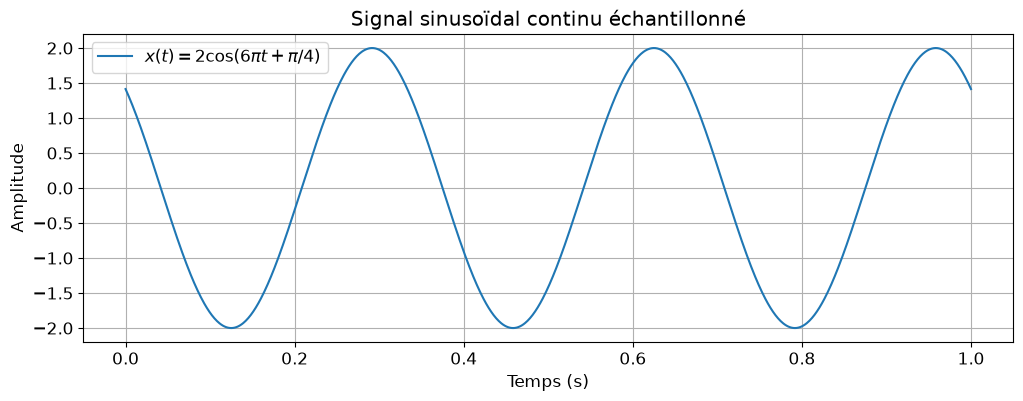

In [2]:
# Paramètres
A = 2.0
f = 3.0          # fréquence en Hz
phi = np.pi/4    # phase en radians

# Temps
t = np.linspace(0, 1, 1000)  # 1000 points entre 0 et 1 s

# Signal
x = A * np.cos(2 * np.pi * f * t + phi)

# Tracé
plt.figure(figsize=(12, 4))
plt.plot(t, x, label='$x(t) = 2 \\cos(6\\pi t + \\pi/4)$')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Signal sinusoïdal continu échantillonné')
plt.grid(True)
plt.legend()
plt.show()

## 3.2 Signal sinusoïdal discret

En traitement numérique, on manipule des séquences $x[n]$. Un signal discret peut être obtenu par échantillonnage d'un signal continu avec une période d'échantillonnage $T_e$.

Soit $x[n] = x(n T_e) = A \cos(\omega_0 n + \phi)$ avec $\omega_0 = 2\pi f T_e$ (pulsation numérique).

### Exemple : $x[n] = \cos(\pi n / 6)$

Ici $\omega_0 = \pi/6$, $A=1$, $\phi=0$.

Nous allons générer les échantillons pour $n=0$ à $20$.

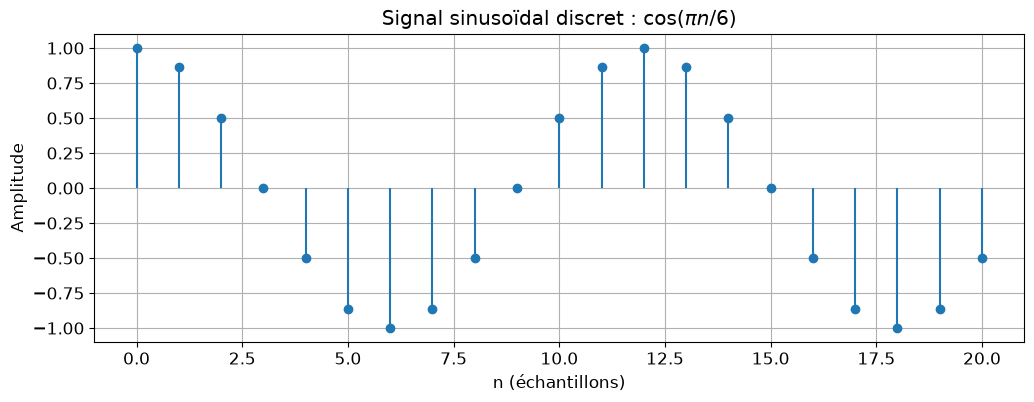

In [3]:
A = 1.0
omega0 = np.pi / 6   # pulsation numérique en rad/échantillon
phi = 0.0

n = np.arange(0, 21)  # indices de 0 à 20

x = A * np.cos(omega0 * n + phi)

# Tracé en bâtons (stem) pour signal discret
plt.figure(figsize=(12, 4))
plt.stem(n, x, basefmt=' ')
plt.xlabel('n (échantillons)')
plt.ylabel('Amplitude')
plt.title('Signal sinusoïdal discret : $\\cos(\\pi n / 6)$')
plt.grid(True)
plt.show()

## 3.3 Influence des paramètres

Modifions l'amplitude, la fréquence et la phase pour observer les changements.

### Exemple : comparer plusieurs signaux

Nous allons tracer trois signaux :
- $x_1[n] = \cos(\pi n / 4)$
- $x_2[n] = 2 \cos(\pi n / 4)$ (amplitude doublée)
- $x_3[n] = \cos(\pi n / 4 + \pi/3)$ (phase décalée)

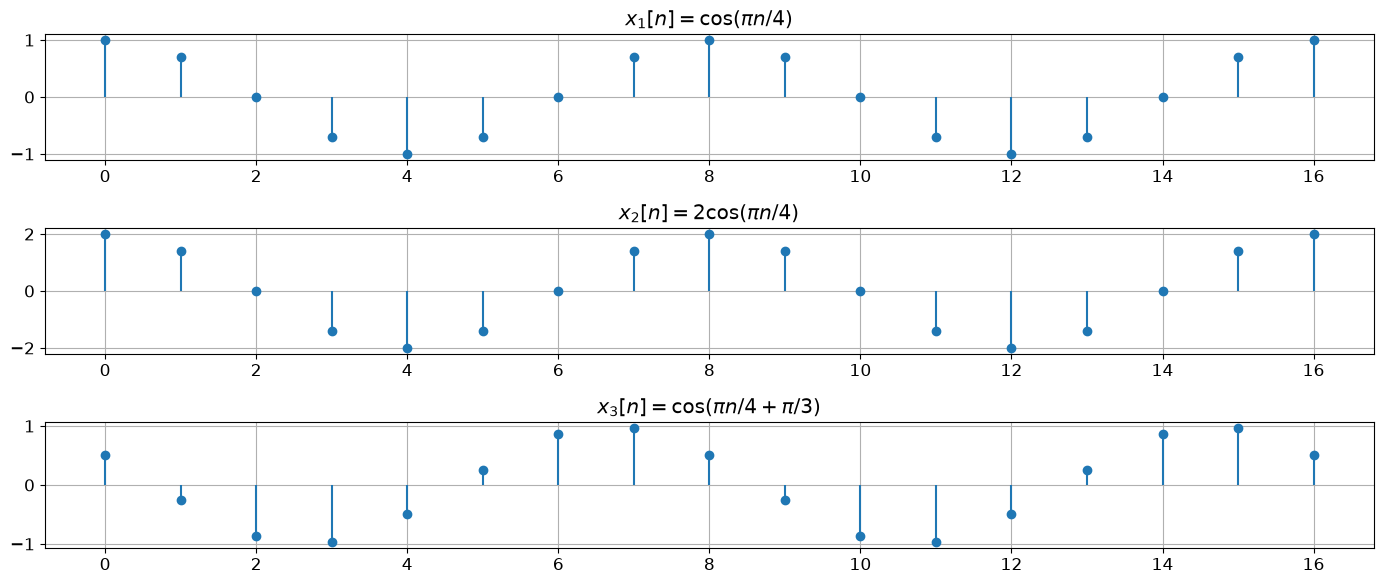

In [4]:
n = np.arange(0, 17)  # indices

x1 = np.cos(np.pi/4 * n)
x2 = 2 * np.cos(np.pi/4 * n)
x3 = np.cos(np.pi/4 * n + np.pi/3)

plt.figure(figsize=(14, 6))

plt.subplot(3, 1, 1)
plt.stem(n, x1, basefmt=' ')
plt.title('$x_1[n] = \\cos(\\pi n/4)$')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.stem(n, x2, basefmt=' ')
plt.title('$x_2[n] = 2 \\cos(\\pi n/4)$')
plt.grid(True)

plt.subplot(3, 1, 3)
plt.stem(n, x3, basefmt=' ')
plt.title('$x_3[n] = \\cos(\\pi n/4 + \\pi/3)$')
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Représentation complexe d'un signal sinusoïdal

Un signal réel $x(t) = A \cos(\omega t + \phi)$ peut être vu comme la partie réelle de $z(t) = A e^{j(\omega t + \phi)}$.

La partie imaginaire correspond alors à $A \sin(\omega t + \phi)$.

Nous allons générer l'exponentielle complexe correspondante et afficher ses parties réelle et imaginaire.

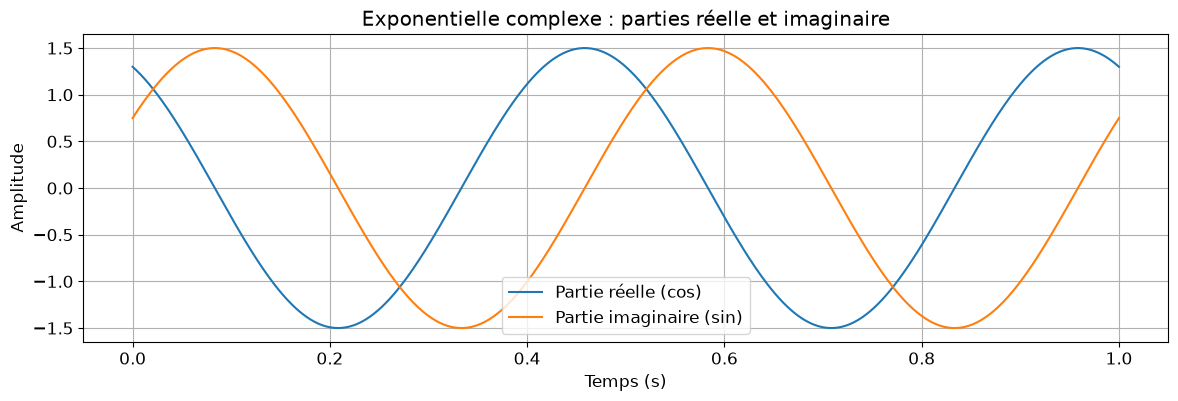

In [5]:
A = 1.5
f = 2.0          # Hz
phi = np.pi/6

t = np.linspace(0, 1, 500)

z = A * np.exp(1j * (2 * np.pi * f * t + phi))

real_part = np.real(z)   # A cos(...)
imag_part = np.imag(z)   # A sin(...)

plt.figure(figsize=(14, 4))
plt.plot(t, real_part, label='Partie réelle (cos)')
plt.plot(t, imag_part, label='Partie imaginaire (sin)')
plt.xlabel('Temps (s)')
plt.ylabel('Amplitude')
plt.title('Exponentielle complexe : parties réelle et imaginaire')
plt.grid(True)
plt.legend()
plt.show()

# 5. Activités des étudiants (Devoir / TP noté)

## Partie 1 – Manipulation des nombres complexes (30 %)

Soit $z_1 = 3 + 4j$ et $z_2 = 1 - 2j$.

1. Calculer $z_1 + z_2$, $z_1 - z_2$, $z_1 \times z_2$, $z_1 / z_2$ (utiliser Python ou le faire à la main).
2. Calculer le module et l'argument de $z_1$ et $z_2$.
3. Écrire $z_1$ et $z_2$ sous forme polaire.

## Partie 2 – Génération de signaux sinusoïdaux (40 %)

1. Générer et tracer le signal $x(t) = 3 \cos(4\pi t - \pi/3)$ pour $t$ de 0 à 2 s.
2. Générer le signal discret $x[n] = \sin(\pi n / 8)$ pour $n=0$ à $30$.
3. Créer un signal composé de la somme de deux sinusoïdes : $x(t) = \cos(2\pi \cdot 5 t) + 0.5 \sin(2\pi \cdot 10 t)$. Afficher ce signal sur l'intervalle [0, 0.5] s.

## Partie 3 – Représentation complexe (30 %)

Soit $x(t) = 2 \cos(3t + \pi/4)$.

1. Écrire l'exponentielle complexe associée $z(t)$.
2. Générer et tracer les parties réelle et imaginaire de $z(t)$ sur l'intervalle $t \in [0, 2\pi]$.
3. Vérifier que la partie réelle correspond bien au signal original.

---

**Livrable** : Rendez un notebook Jupyter contenant vos codes et vos commentaires (ou un fichier Python).

**Conseil** : Utilisez `numpy` et `matplotlib` pour les tracés. N'oubliez pas de commenter vos codes.

**Date de rendu** : à définir par l'enseignant.

---
